In [1]:
# setup environment
import pathlib
import numpy as np
import matplotlib.pyplot as plt

# create higher resolution plots
%config InlineBackend.figure_format = 'retina'

# set directory
filesDir = pathlib.Path('.')

In [2]:
# load data
samples = {}
samples['param0'] = np.load(filesDir/'noise_correlated_Nt1000_Nsim10000_correlation.npy')
samples['param1'] = np.load(filesDir/'noise_correlated_Nt1000_Nsim10000_stddev.npy')
samples['state']  = np.load(filesDir/'noise_correlated_Nt1000_Nsim10000_data.npy')
n_samples = samples['param0'].shape[0]

print('#samples', n_samples)
for key in samples.keys():
    print(f"{key}\t{samples[key].shape}, {samples[key].dtype}")

#samples 10000
param0	(10000,), float32
param1	(10000,), float32
state	(10000, 1000), float32


In [3]:
# split samples into training and testing
samples_train = {}
samples_test  = {}
n_samples_test = 2000

for key in samples.keys():
    samples_train[key] = samples[key][:-n_samples_test,...]
    samples_test[key]  = samples[key][-n_samples_test:,...]

print('#samples', n_samples)
for key in samples_train.keys():
    print(f"samples_train: {key}\t{samples_train[key].shape}, {samples_train[key].dtype}")
for key in samples_test.keys():
    print(f"samples_test: {key}\t{samples_test[key].shape}, {samples_test[key].dtype}")

#samples 10000
samples_train: param0	(8000,), float32
samples_train: param1	(8000,), float32
samples_train: state	(8000, 1000), float32
samples_test: param0	(2000,), float32
samples_test: param1	(2000,), float32
samples_test: state	(2000, 1000), float32


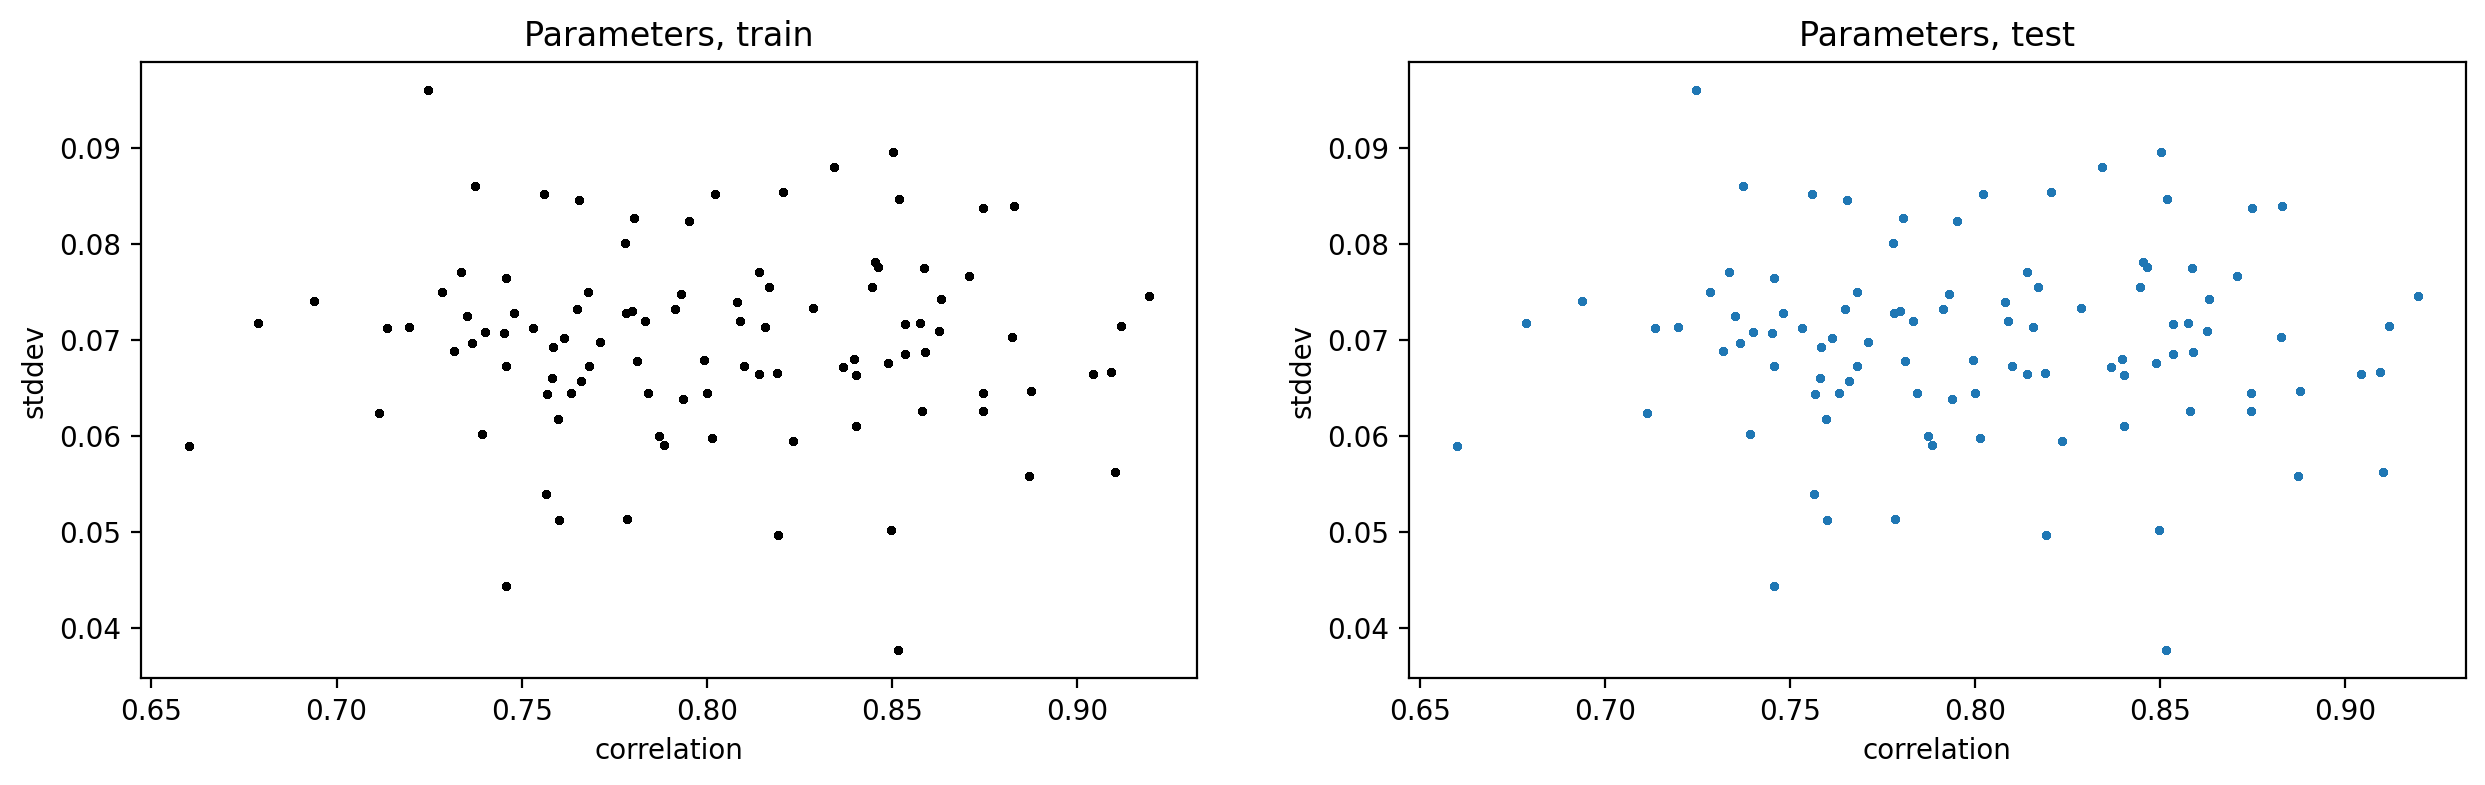

In [4]:
# create plots
fig, ax = plt.subplots(1, 2, figsize=(5*3, 4))

ax[0].scatter(samples_train['param0'], samples_train['param1'], s=2**2, color='black')
ax[0].set_title('Parameters, train')
ax[0].set_xlabel('correlation')
ax[0].set_ylabel('stddev')

ax[1].scatter(samples_test['param0'], samples_test['param1'], s=2**2, color='tab:blue')
ax[1].set_title('Parameters, test')
ax[1].set_xlabel('correlation')
ax[1].set_ylabel('stddev')

plt.show()